In [1]:
import os
import sys
# set gpu to be pci bus id
# os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
# os.environ['CUDA_VISIBLE_DEVICES'] = '2'
os.environ["JAX_PLATFORM_NAME"] = "cpu"
# set gpu memory usage and turnoff pre-allocated memory TODO: what does the following do??
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] ='false'
# os.environ['XLA_PYTHON_CLIENT_ALLOCATOR']='platform'
# os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [2]:
import jax
from jax import random
from jax import lax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import equinox as eqx
from typing import Tuple, Optional

##### PSF LAYER!!!
Just copied and psated from lensless_imaging_system.py

In [3]:
class RMLPSFLayer(eqx.Module):
    """ A layer that models the Random Multi-Focal Lenslet Point Spread Function using Gaussians."""
    # model PSF layer as a bunch of gaussians 
    means: jnp.ndarray # (N, 2) array of Gaussian centers 
    covs: jnp.ndarray # (N, 2, 2) array of Gaussian covariances
    weights: jnp.ndarray # (N,) array of Gaussian weights
    object_size: int # don't make them eqx.field(static=True) it can break
    obj_padding: tuple
    psf_padding: tuple
    num_gaussians: int
    grid: jnp.ndarray # cached coordinate grid 
    psf_shape: tuple # static PSF shape
    measurement_bias: float # static measurement bias

    def __init__(self, object_size: int, num_gaussians: int, psf_size: Tuple[int, int] = (32, 32), measurement_bias: Optional[float] = 0.0, key: Optional[jax.random.PRNGKey] = None):
        super().__init__()
        key = jax.random.PRNGKey(0) if key is None else key
        self.num_gaussians = num_gaussians
        self.object_size = object_size
        self.psf_shape = psf_size
        self.measurement_bias = measurement_bias

        # including psf_size shape to ensure it's square 
        assert psf_size[0] == psf_size[1], "PSF size must be square."

        # initialize means randomly within the PSF bounds 
        k1, k2, k3 = jax.random.split(key, 3) 
        # Create a grid of means uniformly spaced across the PSF
        grid_size = int(jnp.ceil(jnp.sqrt(num_gaussians)))
        x = jnp.linspace(-psf_size[0]/2*.7, psf_size[0]/2*.7, grid_size)
        y = jnp.linspace(-psf_size[1]/2*.7, psf_size[1]/2*.7, grid_size)
        X, Y = jnp.meshgrid(x, y)
        grid_means = jnp.stack([Y.flatten(), X.flatten()], axis=1)
        
        # Take only the number of means we need and add small random perturbations
        self.means = grid_means[:num_gaussians] + jax.random.normal(k1, (num_gaussians, 2)) * (psf_size[0]/grid_size/4)

        # self.means = jax.random.uniform(k1, (num_gaussians, 2), 
        #                             minval = -psf_size[0] // 4,
        #                             maxval = psf_size[0] // 4) # TODO other version uses //3 for spectral, decide which 
        # initialize covariance matrices with random rotation and scale 
        single_scale = jax.random.uniform(k2, (num_gaussians,), minval=1, maxval=5)
        scales = jnp.stack([single_scale, single_scale], axis=1)
        thetas = jax.random.uniform(k3, (num_gaussians,), minval=0, maxval=2*jnp.pi)

        # construct rotation matrices 
        # cos_t = jnp.cos(thetas)
        # sin_t = jnp.sin(thetas)
        # R = jnp.stack([jnp.stack([cos_t, -sin_t], axis=1),
        #             jnp.stack([sin_t, cos_t], axis=1)], axis=1)
        
        # create diagonal matrices with scales 
        # S = jnp.zeros((num_gaussians, 2, 2))
        # S = S.at[:, 0, 0].set(scales[:, 0])
        # S = S.at[:, 1, 1].set(scales[:, 1])

         # Compute covariance matrices: R @ S @ R.T
        # self.covs = jnp.einsum('nij,njk,nkl->nil', R, S, R.transpose(0, 2, 1)) # TODO newer version uses matmul but I like einsum
        self.covs = jnp.stack([jnp.eye(2) * s for s in single_scale])
        # initialize weights uniformly 
        self.weights = jnp.ones(num_gaussians) / num_gaussians

        # padding calculations # TODO skipping this, assume 2D images that are hxw and images are >> object. 
        self.obj_padding = (0, 0) # (H, W format)
        self.psf_padding = (0, 0)

        # create a coordinate grid 
        y = jnp.linspace(-psf_size[0] // 2, psf_size[0] // 2, psf_size[0])
        x = jnp.linspace(-psf_size[1] // 2, psf_size[1] // 2, psf_size[1])
        X, Y = jnp.meshgrid(x, y)
        self.grid = jnp.stack([Y.flatten(), X.flatten()], axis=1)
    
    def compute_psf(self):
        """
        Compute the PSF from the current parameters.
        Ensures energy conservation by normalizing the total sum to 1.
        Returns a square PSF array.
        """
        # Reshape grid for broadcasting
        grid_expanded = self.grid[None, :, :] # (1, H*W, 2)
        means_expanded = self.means[:, None, :] # (N, 1, 2) 

        # Center the coordinates 
        centered = grid_expanded - means_expanded # (N, H*W, 2) 
    
        # Compute quadratic form for each Gaussian 
        covs_inv = jnp.linalg.inv(self.covs) # (N, 2, 2)
        quad_form = jnp.einsum('npi,nij,npj->np', centered, covs_inv, centered) # TODO newer version uses a different operation. 
        # also including a clip from newer version
        quad_form_clipped = jnp.clip(quad_form, a_min=-100, a_max=100)

        # Compute Gaussian values 
        gaussians = jnp.exp(-0.5 * quad_form_clipped) # (N, H*W) 

        # Normalize each gaussian individually to ensure it integrates to 1 
        gaussians = gaussians / (jnp.sum(gaussians, axis=1, keepdims=True) + 1e-10) 

        # Weight and sum the Gaussians 
        weighted_sum = jnp.sum(self.weights[:, None] * gaussians, axis=0)

        # reshape back to square 2D array 
        psf = weighted_sum.reshape(self.psf_shape[0], self.psf_shape[1]) 

        # Normalize to conserve energy
        return psf / (jnp.sum(psf) + 1e-10)
    
    def normalize_psf(self):
        """ Ensure weights sum to 1 and that covariance matrices are positive definite."""
        # ensure positive definite 
        sym_covs = (self.covs + self.covs.transpose(0, 2, 1)) / 2 
        min_eigenvalue = 1e-6 # small positive constant 
        eigvals, eigvecs = jnp.linalg.eigh(sym_covs)
        eigvals = jnp.clip(eigvals, min_eigenvalue, None) # Clip eigenvalues
        min_std = 1
        eigvals = jnp.clip(eigvals, min_std**2, None) # This clip prevents super long-tailed streaks in the learned PSF. 1 works well and doesn't streak.
        new_covs = jnp.einsum("nij,nj,nkj->nik", eigvecs, eigvals, eigvecs) # TODO if any issues switch to the newer version of this? 

        # normalize the weights 
        normalized_weights = self.weights.clip(0) / jnp.sum(self.weights.clip(0) + 1e-10) 

        # constrain the means to be within the PSF bounds 
        means = jnp.clip(self.means, -self.psf_shape[0] // 2*.8, self.psf_shape[0] // 2*.8)

        return eqx.tree_at(
            lambda layer: (layer.covs, layer.weights, layer.means),
            self,
            (new_covs, normalized_weights, means),
        )

In [4]:
def conv2d(x: jnp.ndarray, psf: jnp.ndarray) -> jnp.ndarray:
    psf = psf[::-1, ::-1]
    K, L = psf.shape

    # Pad fully so conv_valid gives the 'full' result
    x_padded = jnp.pad(x, ((0,0), (K-1, K-1), (L-1, L-1)))
    x4 = x_padded[:, :, :, None]
    k4 = psf[:, :, None, None]

    y4 = lax.conv_general_dilated(
        lhs=x4,
        rhs=k4,
        window_strides=(1, 1),
        padding="VALID",
        dimension_numbers=("NHWC", "HWIO", "NHWC"),
    )
    # y4 shape is now (B, H+K-1, W+L-1, 1) — the full convolution output

    # Crop to original size, matching scipy's 'same' anchor
    crop_h = (K - 1) // 2
    crop_w = (L - 1) // 2
    H, W = x.shape[1], x.shape[2]

    return y4[:, crop_h:crop_h+H, crop_w:crop_w+W, 0]

In [5]:
def wiener_deconv(y: jnp.ndarray, psf: jnp.ndarray, K: float) -> jnp.ndarray:
    """
    y:   (B, H, W) — observed blurred image
    psf: (K, L)    — point spread function (same one used in forward model)
    K:   scalar    — noise-to-signal ratio (regularization). larger = more smoothing.
    
    returns: (B, H, W) estimate of original image
    """
    H, W = y.shape[1], y.shape[2]
    psf_h, psf_w = psf.shape

    if psf_h > H or psf_w > W:
        raise ValueError(f"PSF ({psf_h}x{psf_w}) is larger than image ({H}x{W})")
    
    # Embed PSF in the output image domain and shift so the PSF center is at (0,0)
    pad_h = (psf_h - 1) // 2
    pad_w = (psf_w - 1) // 2

    psf_padded = jnp.zeros((H, W))
    psf_padded = psf_padded.at[:psf_h, :psf_w].set(psf)
    # roll so that the center pixel of the PSF lands at (0,0)
    psf_padded = jnp.roll(psf_padded, (-pad_h, -pad_w), axis=(0, 1))

    # FFTs
    PSF = jnp.fft.rfft2(psf_padded)          # (H, W//2+1)
    Y   = jnp.fft.rfft2(y)                   # (B, H, W//2+1)

    # Wiener filter: H* / (|H|^2 + K)
    PSF_conj  = jnp.conj(PSF)
    PSF_power = jnp.abs(PSF) ** 2
    wiener    = PSF_conj / (PSF_power + K)

    X_est = wiener[None, :, :] * Y           # broadcast over batch

    return jnp.fft.irfft2(X_est, s=(H, W))  # (B, H, W)

In [6]:
class E2E(eqx.Module):
    psf_module: eqx.Module
    log_K: jnp.ndarray  # learn in log space to keep K positive

    def __init__(self, psf_module, key=None):
        self.psf_module = psf_module
        self.log_K = jnp.array(-1.0)  # initializes K to ~1e-4

    def __call__(self, x: jnp.ndarray) -> tuple:
        # x: (B, H, W)
        K = jnp.exp(self.log_K)  # ensure K is always positive
        psf = self.psf_module.compute_psf()  # (K, L)
        y = conv2d(x, psf)                   # (B, H, W)
        x_hat = wiener_deconv(y, psf, K)     # (B, H, W)
        return x_hat, y, psf

In [15]:
import numpy as np
def visualize(model, x_batch, epoch):
    x_hat, y, psf = model(x_batch)
    
    x_np    = np.array(x_batch[0])   # first item in batch
    y_np    = np.array(y[0])
    x_hat_np = np.array(x_hat[0])
    psf_np  = np.array(psf)

    f, axarr = plt.subplots(1, 4, figsize=(16, 4))
    axarr[0].imshow(x_np,     cmap='gray'); axarr[0].set_title("x (GT)")
    axarr[1].imshow(y_np,     cmap='gray'); axarr[1].set_title("y (meas)")
    axarr[2].imshow(x_hat_np, cmap='gray'); axarr[2].set_title("x_hat")
    axarr[3].imshow(psf_np,   cmap='gray'); axarr[3].set_title("PSF")
    plt.suptitle(f"Epoch {epoch}")
    plt.tight_layout()
    plt.show()

In [21]:
from lensless_data_generator import LenslessDataGenerator
photon_count = 160
subset_fraction = 0.01 #TODO: CHANGE THIS FRACTION WHEN I FIGURE OUT THE GPU ISSUE
seed_value = 42 #TODO: FIX SEEDING
data_generator = LenslessDataGenerator(photon_count, subset_fraction=subset_fraction, seed=seed_value)
x_train, x_test = data_generator.load_mnist_data()
print(x_train.shape)

(600, 32, 32)


In [19]:
train_dataset = data_generator.create_dataset(
    x_train, 
    tile_rows=1,
    tile_cols=1,
    batch_size=32   
)

def convert_batch(batch):
    """
    Convert a batch from the TensorFlow dataloader to a JAX array.
    
    Args:
        batch: A batch from the TensorFlow dataloader.
    
    Returns:
        The batch converted to a JAX array.
    """
    if isinstance(batch, (tuple, list)):
        # In case the batch is a tuple/list (e.g. (images, labels)), take the first element.
        batch = batch[0]
    if hasattr(batch, "numpy"):
        batch = batch.numpy()
    return jnp.array(batch)

In [ ]:
import optax
model = E2E(psf_module=RMLPSFLayer(object_size=32, num_gaussians=10)) #TODO: do i need object_size?
optimizer = optax.adam(1e-3)
optimizer_state = optimizer.init(eqx.filter(model, eqx.is_array))
print_every  = 1   # print loss every N epochs
visualize_every = 5  # visualize every N epochs
num_epochs = 30

@eqx.filter_jit
def step(model, x_batch, optimizer_state):
    def loss_fn(model):
        x_hat, y, psf = model(x_batch)
        return jnp.mean((x_hat - x_batch) ** 2)
    
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model)
    updates, optimizer_state = optimizer.update(grads, optimizer_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)
    return model, optimizer_state, loss


for epoch in range(num_epochs):
    for tf_batch in train_dataset:
        x_batch = convert_batch(tf_batch)  # (32, 96, 96) — 3x3 tiled 32x32 images
        model, optimizer_state, loss = step(model, x_batch, optimizer_state)

    if epoch % print_every == 0:
        print(f"epoch {epoch}/{num_epochs}  loss={loss:.6f}  K={float(jnp.exp(model.log_K)):.6f}")

    if epoch % visualize_every == 0:
        visualize(model, x_batch, epoch)

##### SANITY CHECKS

In [11]:
import numpy as np
from scipy.signal import convolve2d

# generate some test image
K = 32
image = np.zeros((K, K))
image[4:10, 4:10] = 1.0
image[10:22, 22:27] = 1.0
image[26:30, 6:24] = 1.0
image = image / np.sum(image)
image = image.astype(np.float32)

# get my psf
psf_mod = RMLPSFLayer(96, 3)
psf = psf_mod.compute_psf()
psf_np = np.array(psf)             

#convolve using my conv2d
jax_img = jnp.array(image)
batched_img = jax_img[None, :, :] #new shape = (1, 32, 32)
convolved_img = conv2d(batched_img, psf)
convolved_img_np = np.squeeze(np.array(convolved_img))

#convolve using scipy convolve2d
result = convolve2d(image, psf_np, mode='same')

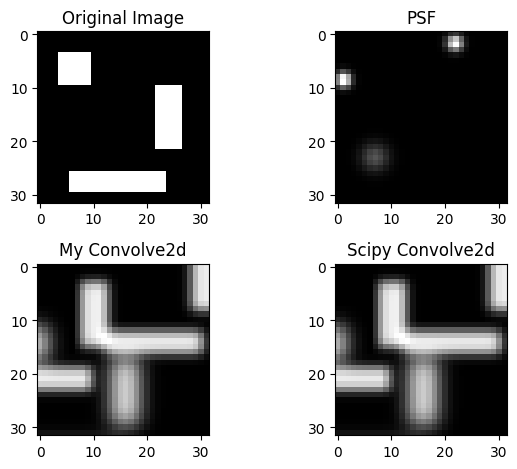

In [12]:
f, axarr = plt.subplots(2,2)
axarr[0,0].imshow(image, cmap='gray')
axarr[0,0].set_title("Original Image")
axarr[0,1].imshow(psf_np, cmap='gray')
axarr[0,1].set_title("PSF")
axarr[1,0].imshow(convolved_img_np, cmap='gray')
axarr[1,0].set_title("My Convolve2d")
axarr[1,1].imshow(result, cmap='gray')
axarr[1,1].set_title("Scipy Convolve2d")
plt.tight_layout()

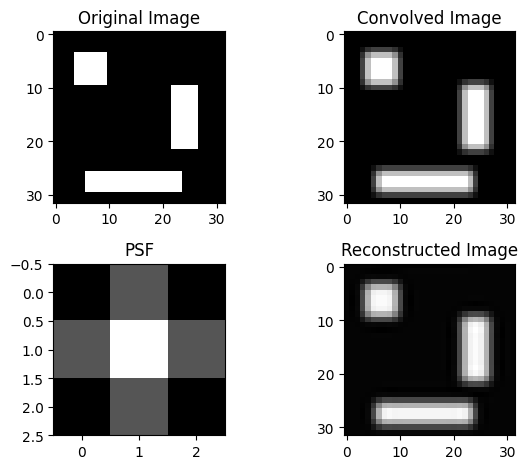

In [13]:
convolved_img.shape
dummy_psf = np.array([[1, 2, 1],
                [2, 4, 2],
                [1, 2, 1]], dtype=float)
dummy_psf = dummy_psf / dummy_psf.sum()  # normalize — important!
dummy_psf = jnp.array(dummy_psf)
dummy_psf_convolved = conv2d(batched_img, dummy_psf)
reconstruction = wiener_deconv(dummy_psf_convolved, dummy_psf, K=1)
reconstruction_np = np.squeeze(np.array(reconstruction))

f, axarr = plt.subplots(2,2)
axarr[0, 0].imshow(image, cmap='gray')
axarr[0, 0].set_title("Original Image")
axarr[0, 1].imshow(np.squeeze(np.array(dummy_psf_convolved)), cmap='gray')
axarr[0, 1].set_title("Convolved Image")
axarr[1, 0].imshow(dummy_psf, cmap='gray')
axarr[1, 0].set_title("PSF")
axarr[1, 1].imshow(reconstruction_np, cmap='gray')
axarr[1, 1].set_title("Reconstructed Image")
plt.tight_layout()
plt.show()

sanity check training loop

In [ ]:
#copied and paste
# for epoch in range(num_epochs):
#     for x_batch in dataloader:
#         x_batch = jnp.array(x_batch)
#         model, optimizer_state, loss = step(model, x_batch, optimizer_state)

#     if epoch % print_every == 0:
#         print(f"epoch {epoch}/{num_epochs}  loss={loss:.6f}  K={float(jnp.exp(model.log_K)):.6f}")

#     if epoch % visualize_every == 0:
#         visualize(model, x_batch, epoch)

epoch 0/300  loss=0.000005  K=0.367519


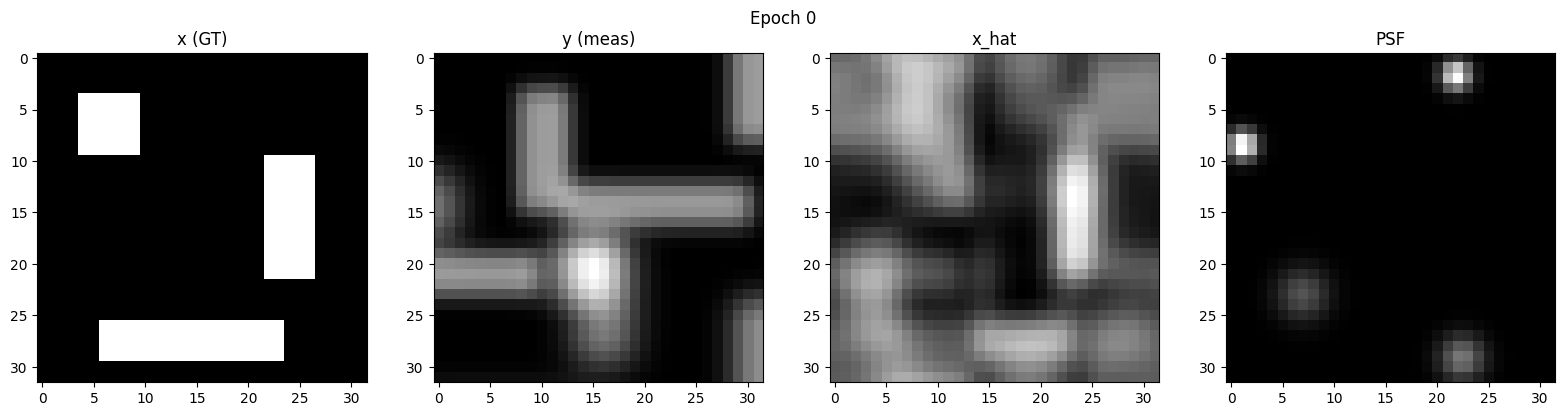

epoch 10/300  loss=0.000005  K=0.363932
epoch 20/300  loss=0.000004  K=0.360362
epoch 30/300  loss=0.000004  K=0.356800
epoch 40/300  loss=0.000004  K=0.353241
epoch 50/300  loss=0.000004  K=0.349684


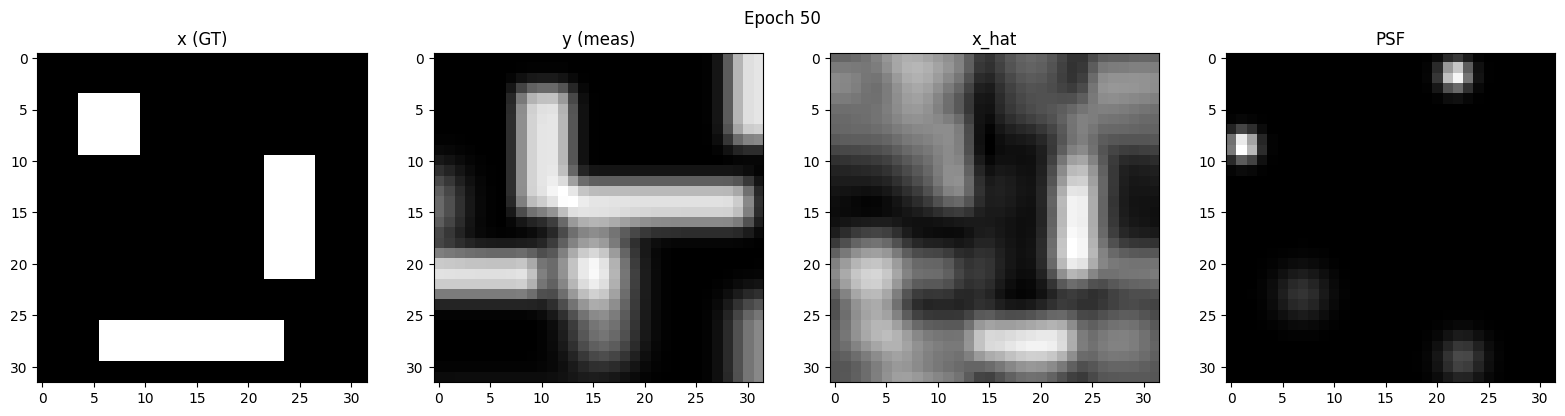

epoch 60/300  loss=0.000004  K=0.346133
epoch 70/300  loss=0.000004  K=0.342591
epoch 80/300  loss=0.000004  K=0.339064
epoch 90/300  loss=0.000004  K=0.335558
epoch 100/300  loss=0.000004  K=0.332077


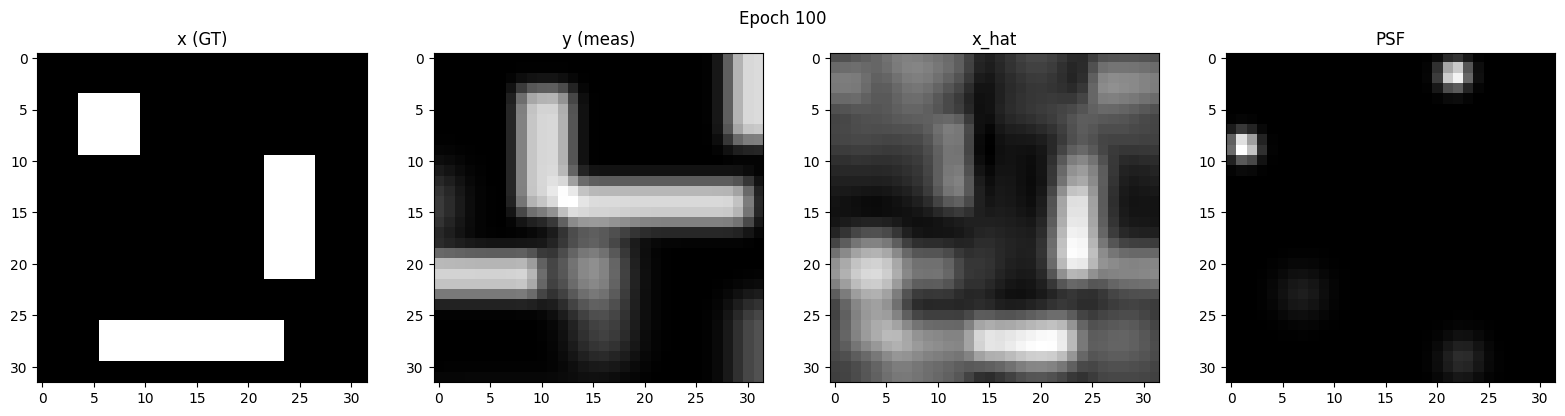

epoch 110/300  loss=0.000004  K=0.328627
epoch 120/300  loss=0.000004  K=0.325209
epoch 130/300  loss=0.000004  K=0.321824
epoch 140/300  loss=0.000004  K=0.318469
epoch 150/300  loss=0.000004  K=0.315132


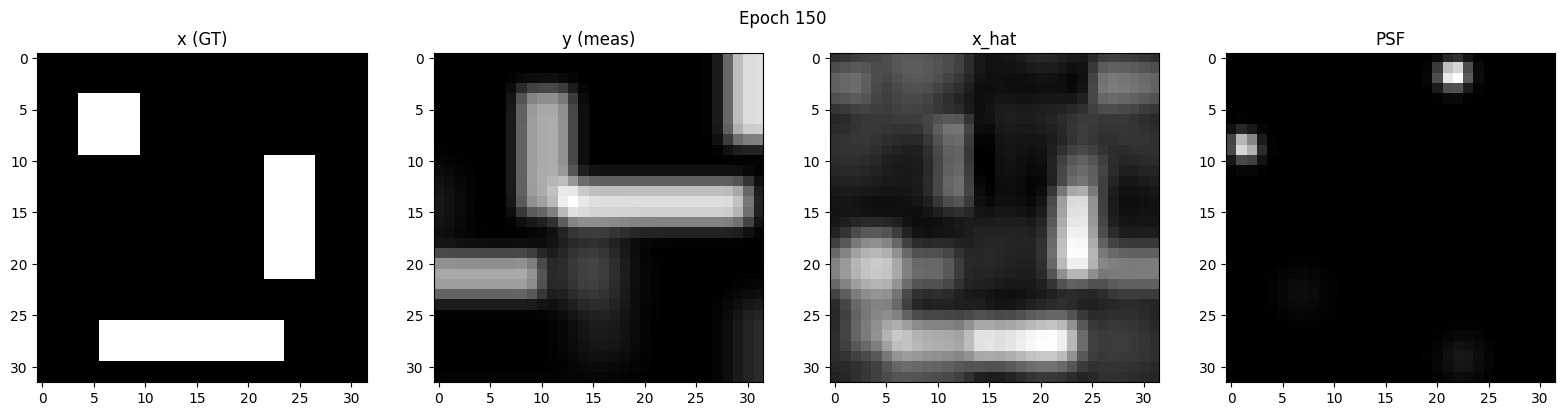

epoch 160/300  loss=0.000004  K=0.311792
epoch 170/300  loss=0.000004  K=0.308434
epoch 180/300  loss=0.000003  K=0.305061
epoch 190/300  loss=0.000003  K=0.301713
epoch 200/300  loss=0.000003  K=0.298457


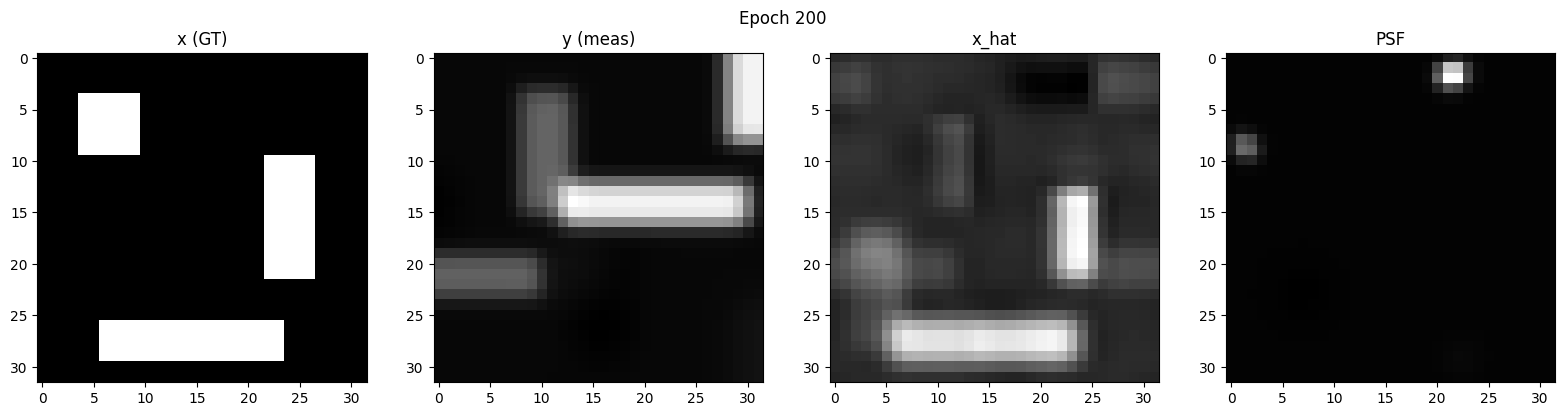

epoch 210/300  loss=0.000003  K=0.295376
epoch 220/300  loss=0.000003  K=0.292540
epoch 230/300  loss=0.000003  K=0.289993
epoch 240/300  loss=0.000003  K=0.287750
epoch 250/300  loss=0.000003  K=0.285798


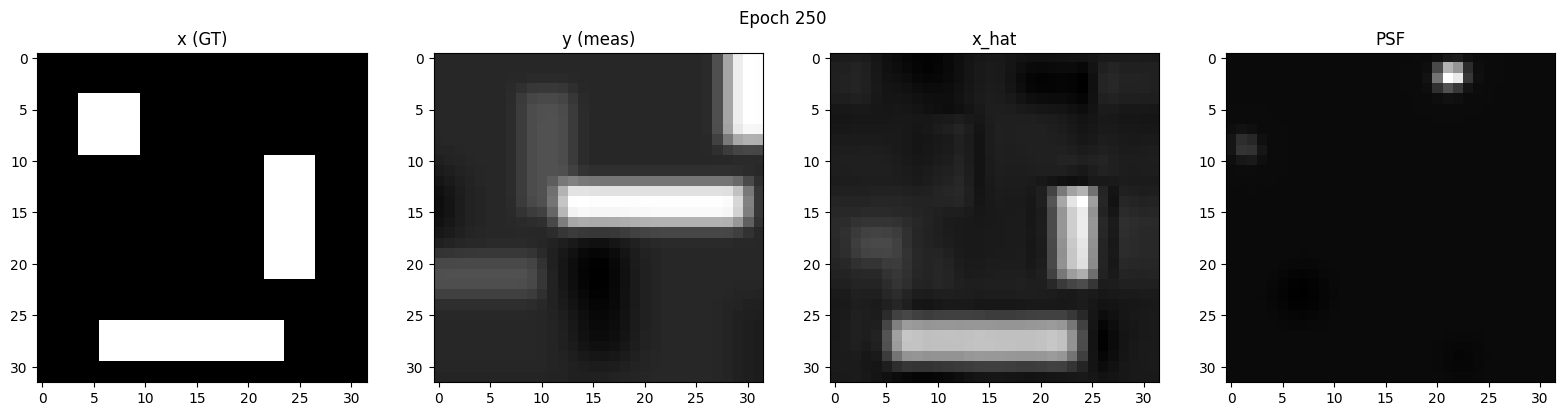

epoch 260/300  loss=0.000003  K=0.284109
epoch 270/300  loss=0.000003  K=0.282643
epoch 280/300  loss=0.000003  K=0.281360
epoch 290/300  loss=0.000003  K=0.280218


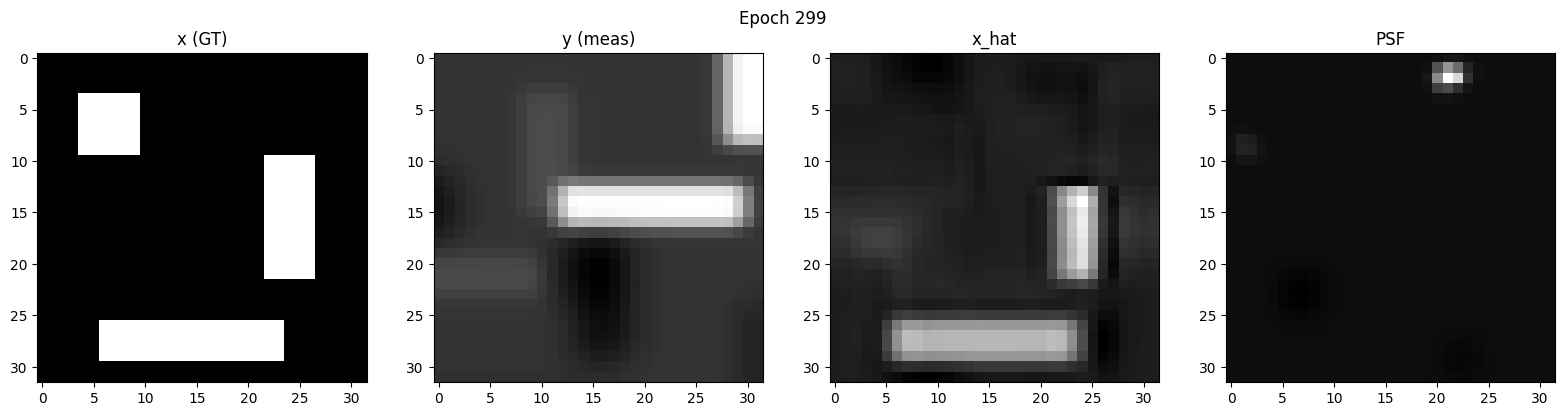

In [82]:
# setup — just use your single image
import optax
x_batch = jnp.array(image)[None, :, :]  # (1, H, W) — batch size of 1

model = E2E(psf_module=RMLPSFLayer(object_size=32, num_gaussians=4))
optimizer = optax.adam(1e-3)
optimizer_state = optimizer.init(eqx.filter(model, eqx.is_array))
print_every  = 10   # print loss every N epochs
visualize_every = 50  # visualize every N epochs
num_epochs = 300

@eqx.filter_jit
def step(model, x_batch, optimizer_state):
    def loss_fn(model):
        x_hat, y, psf = model(x_batch)
        return jnp.mean((x_hat - x_batch) ** 2)
    
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model)
    updates, optimizer_state = optimizer.update(grads, optimizer_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)
    return model, optimizer_state, loss

for epoch in range(num_epochs):
    model, optimizer_state, loss = step(model, x_batch, optimizer_state)

    if epoch % print_every == 0:
        print(f"epoch {epoch}/{num_epochs}  loss={loss:.6f}  K={float(jnp.exp(model.log_K)):.6f}")

    if epoch % visualize_every == 0:
        visualize(model, x_batch, epoch)

visualize(model, x_batch, epoch)